<a href="https://colab.research.google.com/github/NatShed/MO_Attack/blob/main/lab5_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 5. Итеративные и оптимизационные атаки: PGD, C&W, JSMA

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 4**

**Формат:** индивидуально или в парах

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить методы построения многошаговых и оптимизационных evasion-атак и научиться сравнивать их по силе, вычислительной стоимости и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- реализовывать PGD-атаку с проекцией на $L_\infty$-шар и случайным стартом;
- объяснять формулировку седловой точки (min-max) и её связь с adversarial training;
- реализовывать целевую C&W L2-атаку с заменой переменных через tanh и параметром confidence κ;
- реализовывать JSMA на основе якобиана выхода модели и точечного насыщения признаков;
- сравнивать атаки по Attack Success Rate, норме возмущения и вычислительным затратам.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Атаки на MNIST могут занимать заметное время на CPU (особенно JSMA) — рассчитывайте время выполнения заранее.


## 0. Подготовка окружения

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Часть I. Данные и базовая модель

**Задание:** загрузите MNIST и обучите небольшую CNN (2 свёрточных слоя + полносвязный классификатор) — эта модель станет целью для всех атак в работе.

In [ ]:
# TODO: загрузите MNIST через torchvision.datasets

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.88MB/s]


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# TODO: реализуйте класс CNN (2 свёрточных слоя, max pooling, полносвязный классификатор)
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 28 -> 14
        x = self.pool(F.relu(self.conv2(x)))   # 14 -> 7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
# TODO: обучите модель на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

model = SmallCNN().to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
crit = nn.CrossEntropyLoss()

# TODO: цикл обучения
for epoch in range(3):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        opt.zero_grad()
        loss = crit(model(images), labels)
        loss.backward()
        opt.step()
    print(f"Epoch {epoch+1} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done


In [ ]:
# TODO: оцените точность на тестовой выборке (clean accuracy)
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        correct += (model(images).argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
clean_accuracy = correct / total
print(f"Clean accuracy: {clean_accuracy:.4f}")


Clean accuracy: 0.9879


## Часть II. Projected Gradient Descent (PGD)

### 2.1. Реализация PGD

**Задание:** реализуйте функцию PGD-атаки по формуле

$ x^{t+1} = \Pi_{x+\mathcal{S}} \left( x^t + \alpha \cdot \text{sign}$nabla_x L$theta, x^t, y)) \right) $

Функция должна:
1. Инициализировать возмущение случайно внутри \$epsilon$-шара (random start).
2. На каждой итерации пересчитывать градиент и делать шаг по знаку градиента.
3. Проецировать (clip) возмущение на \$epsilon$-шар и итоговый пиксель — на диапазон $[0,1]$.

ε-шар — это множество всех точек, которые находятся на расстоянии не больше ε от центральной точки.

Простыми словами: это «область допустимых изменений» вокруг исходного изображения.

сделать много маленьких шагов по градиенту, каждый раз проецируя обратно в ε-шар, найти лучшу. точку в этом шаре.

In [ ]:
# TODO: реализуйте функцию PGD-атаки
def pgd_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    """
    PGD (Projected Gradient Descent) — итеративная L∞-атака.

    Формула:
        x^{t+1} = Π_{x+S}( x^t + α · sign(∇_x L(θ, x^t, y)) )

    Аргументы:
        model:      обученная нейросеть
        x:          батч изображений [B, C, H, W]
        y:          батч меток [B]
        epsilon:    бюджет L∞-возмущения (радиус шара)
        alpha:      размер шага (обычно ε/4 или 2ε/num_iter)
        num_iter:   число итераций (обычно 20–40)
        criterion:  функция потерь (CrossEntropyLoss)
        randomize:  случайный старт внутри ε-шара

    Возвращает:
        x_adv: adversarial-примеры той же формы, что и x
    """
    # 1. Инициализация delta — случайная или нулевая
    if randomize:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    else:
        delta = torch.zeros_like(x)

    # Обрезаем начальную точку в допустимый диапазон [0, 1]
    delta = torch.clamp(x + delta, 0.0, 1.0) - x
    delta.requires_grad_(True)

    # 2. Итеративный цикл
    for _ in range(num_iter):
        # Прямой проход через модель на возмущённом входе
        logits = model(x + delta)
        loss = criterion(logits, y)

        # Обратный проход: считаем градиент loss по delta
        model.zero_grad()
        loss.backward()

        # Обновляем delta БЕЗ отслеживания градиента
        with torch.no_grad():
            # Шаг по знаку градиента (максимизация loss)
            delta.data = delta.data + alpha * delta.grad.sign()

            # Проекция №1: ограничиваем delta в ε-шар по L∞-норме
            delta.data = torch.clamp(delta.data, -epsilon, epsilon)

            # Проекция №2: x + delta должно быть в [0, 1]
            delta.data = torch.clamp(x + delta.data, 0.0, 1.0) - x

            # Обнуляем градиент перед следующей итерацией
            delta.grad.zero_()

    # Возвращаем финальный adversarial-пример
    return (x + delta).detach()


### 2.2. Визуализация: FGSM vs PGD

**Задание:** реализуйте FGSM (для сравнения), затем на одном тестовом примере постройте adversarial-версии обоими методами при одинаковом \$epsilon$ и визуализируйте результат (3 подграфика: оригинал, FGSM, PGD) с указанием предсказаний модели.

In [ ]:
# TODO: реализуйте FGSM (напоминание из предыдущей лабораторной)
def fgsm_attack(model, x, y, epsilon, criterion):
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss = criterion(logits, y)
    model.zero_grad()
    loss.backward()
    x_adv = x + epsilon * x_adv.grad.sign()
    return torch.clamp(x_adv, 0, 1).detach()


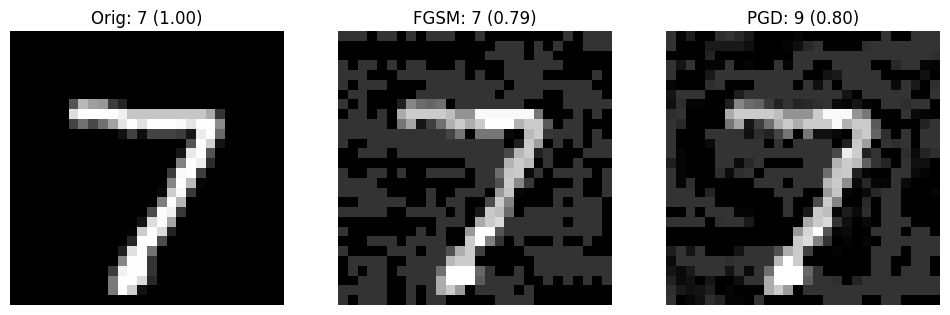

In [ ]:
# TODO: выберите тестовый пример
# TODO: примените fgsm_attack и pgd_attack с epsilon=0.2 (для PGD: alpha=0.02, num_iter=40)
# TODO: постройте визуализацию из 3 подграфиков с предсказаниями модели
images, labels = next(iter(test_loader))
img = images[0:1].to(device)
label = labels[0:1].to(device)

eps = 0.2
alpha = 0.02
num_iter = 40

img_fgsm = fgsm_attack(model, img, label, eps, crit)
img_pgd  = pgd_attack(model, img, label, eps, alpha, num_iter, crit)

def predict(m, x):
    m.eval()
    with torch.no_grad():
        logits = m(x)
        prob = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1).item()
        conf = prob[0, pred].item()
    return pred, conf

pred_clean, conf_clean = predict(model, img)
pred_fgsm,  conf_fgsm  = predict(model, img_fgsm)
pred_pgd,   conf_pgd   = predict(model, img_pgd)

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(img.cpu().squeeze(), cmap='gray'); axes[0].set_title(f"Orig: {pred_clean} ({conf_clean:.2f})"); axes[0].axis('off')
axes[1].imshow(img_fgsm.cpu().squeeze(), cmap='gray'); axes[1].set_title(f"FGSM: {pred_fgsm} ({conf_fgsm:.2f})"); axes[1].axis('off')
axes[2].imshow(img_pgd.cpu().squeeze(), cmap='gray'); axes[2].set_title(f"PGD: {pred_pgd} ({conf_pgd:.2f})"); axes[2].axis('off')
plt.show()

**Вопрос для отчёта:** отличаются ли визуально возмущения FGSM и PGD? Какой метод успешнее меняет предсказание модели при одном и том же ε?

Возмущения FGSM более размазаны по всей картинке, в отличе от PGD, гд возмущения больше сконцентрированы на контурах 7. Что успешнее. PGD. На показанном примере (цифра 7, на которой модель уверена с confidence 1.000) FGSM при
 не смог сменить предсказание: класс остался 7, уверенность упала до 0.79. PGD при том же бюджете меняет предсказание на неверный класс (предсказывает 9), причём с высокой уверенностью.

### 2.3. Attack Success Rate: FGSM vs PGD

**Задание:** постройте график зависимости Attack Success Rate от бюджета $\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}$ для FGSM и PGD (20 итераций) на одном графике.

ε = 0.00 | FGSM: 0.0000 | PGD: 0.0000
ε = 0.02 | FGSM: 0.0107 | PGD: 0.0111
ε = 0.05 | FGSM: 0.0398 | PGD: 0.0505
ε = 0.10 | FGSM: 0.1332 | PGD: 0.2076
ε = 0.15 | FGSM: 0.3233 | PGD: 0.5666
ε = 0.20 | FGSM: 0.5980 | PGD: 0.8787
ε = 0.30 | FGSM: 0.9388 | PGD: 0.9948


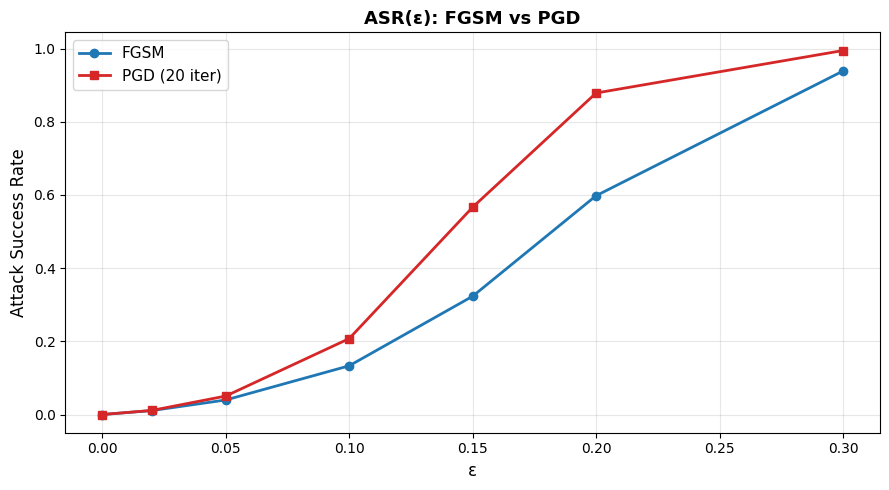

In [ ]:
def evaluate_asr(model, loader, attack_fn, criterion, n_batches=10, **attack_kwargs):
    """Универсальная оценка ASR."""
    model.eval()
    success = 0
    total = 0

    for i, (images, labels) in enumerate(loader):
        if i >= n_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            clean_preds = model(images).argmax(dim=1)
        mask = clean_preds == labels
        images = images[mask]
        labels = labels[mask]

        if len(images) == 0:
            continue

        # ← criterion идёт в атаку
        x_adv = attack_fn(model, images, labels, criterion=criterion, **attack_kwargs)

        with torch.no_grad():
            adv_preds = model(x_adv).argmax(dim=1)

        success += (adv_preds != labels).sum().item()
        total += labels.size(0)

    return success / total if total > 0 else 0.0


# ============================================================
# Расчёт ASR для FGSM и PGD
# ============================================================
epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

asr_fgsm = []
asr_pgd  = []

for e in epsilons:
    a_f = evaluate_asr(model, test_loader, fgsm_attack, crit,
                       n_batches=10, epsilon=e)
    a_p = evaluate_asr(model, test_loader, pgd_attack,  crit,
                       n_batches=10, epsilon=e, alpha=0.01, num_iter=20)
    asr_fgsm.append(a_f)
    asr_pgd.append(a_p)
    print(f"ε = {e:.2f} | FGSM: {a_f:.4f} | PGD: {a_p:.4f}")


# ============================================================
# График
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(epsilons, asr_fgsm, marker='o', lw=2, label="FGSM", color='#1f77b4')
plt.plot(epsilons, asr_pgd,  marker='s', lw=2, label="PGD (20 iter)", color='#d62728')
plt.title("ASR(ε): FGSM vs PGD", fontweight='bold', fontsize=13)
plt.xlabel("ε", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Успешность атаки PGD растет круче. и к сдвигу 0,2 уже почти достигла максимума.

### 2.4. Влияние числа итераций PGD

**Задание:** зафиксируйте $\epsilon = 0.15$ и постройте график зависимости ASR от числа итераций PGD $\in \{1, 2, 5, 10, 20, 40, 80\}$. Определите, при каком числе итераций ASR стабилизируется (перестаёт заметно расти).

In [ ]:
# TODO: рассчитайте ASR для разного числа итераций PGD при фиксированном epsilon=0.15
# TODO: постройте график
EPS_FIXED = 0.15
ALPHA = 0.01   # шаг PGD (обычно ε/15 или ε/20)
iters_list = [1, 2, 5, 10, 20, 40, 80]

asr_vs_iters = []

for it in iters_list:
    asr = evaluate_asr(
        model, test_loader, pgd_attack, crit,
        n_batches=10,
        epsilon=EPS_FIXED,
        alpha=ALPHA,
        num_iter=it,
        randomize=True
    )
    asr_vs_iters.append(asr)
    print(f"num_iter = {it:>3} → ASR = {asr:.4f}")

num_iter =   1 → ASR = 0.0087
num_iter =   2 → ASR = 0.0203
num_iter =   5 → ASR = 0.0759
num_iter =  10 → ASR = 0.2346
num_iter =  20 → ASR = 0.5666
num_iter =  40 → ASR = 0.6588
num_iter =  80 → ASR = 0.6795


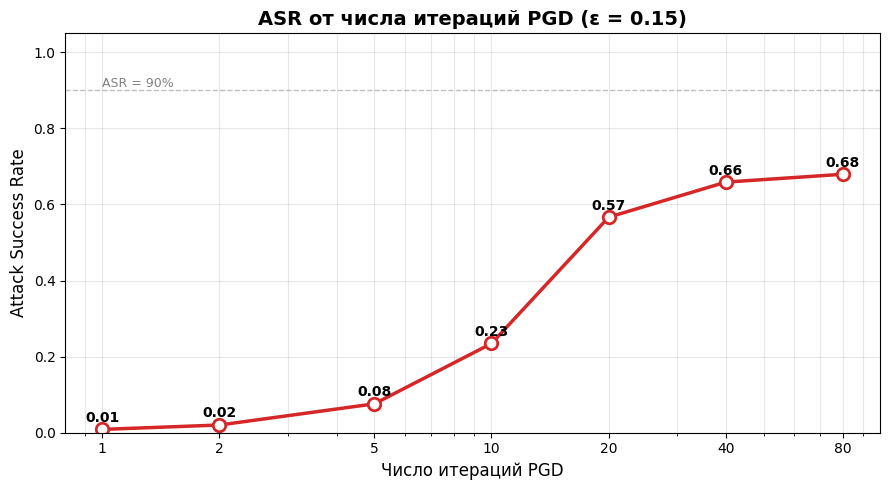

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(iters_list, asr_vs_iters,
         marker='o', markersize=9, linewidth=2.5, color='#d62728',
         markerfacecolor='white', markeredgewidth=2)

plt.title("ASR от числа итераций PGD (ε = 0.15)",
          fontweight='bold', fontsize=14)
plt.xlabel("Число итераций PGD", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.xscale('log')                     # логарифмическая шкала — удобнее для [1..80]
plt.xticks(iters_list, iters_list)    # показываем реальные значения
plt.ylim(0, 1.05)
plt.grid(alpha=0.3, which='both')

# Подписи значений над точками
for it, asr in zip(iters_list, asr_vs_iters):
    plt.text(it, asr + 0.02, f"{asr:.2f}",
             ha='center', fontsize=10, fontweight='bold')

# Горизонтальные ориентиры
plt.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.text(1, 0.91, "ASR = 90%", fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** при каком числе итераций ASR практически перестаёт расти? Как это соотносится с утверждением лекции о том, что одношаговая линеаризация (FGSM) даёт лишь нижнюю оценку силы атаки?

Значение выравнялось примерно на 20 итерации.

FGSM = 1 итерация = ASR 0.87% — «нижняя оценка».

PGD = 40 итераций = ASR 65.88%
FGSM даёт лишь нижнюю оценку силы атаки. Это значит, что FGSM показывает минимум того, что можно сломать, но не истинную уязвимость модели.
FGSM делает один шаг — но этот шаг не оптимальный. Он использует линейную аппроксимацию функции потерь, которая точна только в маленькой окрестности точки.

Проблема: при большом ε линейная аппроксимация ломается. Настоящий ландшафт функции потерь нелинейный, и один шаг по градиенту промахивается мимо настоящего максимума.

PGD решает эту проблему: он делает много маленьких шагов и пересчитывает градиент на каждом. Это позволяет адаптироваться к нелинейности и найти настоящий максимум.



### 2.5. Adversarial training через PGD (седловая точка)

**Задание:** обучите вторую модель с adversarial training по формулировке седловой точки Мадри:

$\min_{\theta} \mathbb{E}_{(x,y)} \left[ \max_{\delta \in \mathcal{S}} L$theta, x+\delta, y) \right] $

На каждом шаге обучения внутренний максимум приближайте PGD с небольшим числом итераций (5-7), а внешний шаг оптимизации делайте по параметрам модели на полученных adversarial-примерах.

In [ ]:
# TODO: реализуйте цикл adversarial training
# На каждом батче:
# 1. Постройте x_adv через pgd_attack (5-7 итераций, epsilon=0.15)
# 2. Посчитайте loss на x_adv
# 3. Сделайте шаг оптимизации

import torch.optim as optim

# Новая модель той же архитектуры
adv_model = SmallCNN().to(device)
opt_adv   = optim.Adam(adv_model.parameters(), lr=1e-3)
crit_adv  = nn.CrossEntropyLoss()

# Параметры adversarial training
EPS_TRAIN  = 0.15     # бюджет L∞-возмущения при обучении
ALPHA_PGD  = 0.02     # шаг PGD внутри цикла
PGD_ITERS  = 7        # число итераций PGD (5-7 — достаточно)
EPOCHS_ADV = 3

In [ ]:
for epoch in range(EPOCHS_ADV):
    adv_model.train()
    running_loss = 0.0
    correct_clean = 0
    correct_adv   = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # --- 1. Внутренний max: строим x_adv через PGD ---
        x_adv = pgd_attack(
            adv_model, images, labels,
            epsilon=EPS_TRAIN,
            alpha=ALPHA_PGD,
            num_iter=PGD_ITERS,
            criterion=crit_adv,
            randomize=True
        )

        # --- 2. Внешний min: шаг по параметрам на x_adv ---
        opt_adv.zero_grad()
        logits_adv = adv_model(x_adv)
        loss = crit_adv(logits_adv, labels)
        loss.backward()
        opt_adv.step()

        # --- Метрики ---
        running_loss += loss.item() * images.size(0)
        correct_adv += (logits_adv.argmax(dim=1) == labels).sum().item()

        # Для справки — accuracy на чистых данных (без шага)
        with torch.no_grad():
            logits_clean = adv_model(images)
            correct_clean += (logits_clean.argmax(dim=1) == labels).sum().item()

        total += labels.size(0)

    print(f"Epoch {epoch+1}/{EPOCHS_ADV} | Loss: {running_loss/total:.4f} | "
          f"Clean Acc: {correct_clean/total:.4f} | Adv Acc: {correct_adv/total:.4f}")

Epoch 1/3 | Loss: 0.6483 | Clean Acc: 0.9118 | Adv Acc: 0.7802
Epoch 2/3 | Loss: 0.2824 | Clean Acc: 0.9785 | Adv Acc: 0.9074
Epoch 3/3 | Loss: 0.2264 | Clean Acc: 0.9841 | Adv Acc: 0.9257


In [ ]:
adv_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        correct += (adv_model(images).argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

adv_clean_accuracy = correct / total

print(f"Обычная модель clean accuracy:       {clean_accuracy:.4f}")
print(f"Adv-trained модель clean accuracy:   {adv_clean_accuracy:.4f}")
print(f"Падение clean accuracy:              {clean_accuracy - adv_clean_accuracy:.4f}")

Обычная модель clean accuracy:       0.9879
Adv-trained модель clean accuracy:   0.9849
Падение clean accuracy:              0.0030


In [ ]:
# TODO: постройте график ASR(epsilon) для adv_model против FGSM и против PGD
# Сравните на одном графике с результатами обычной модели из п.2.3
# ============================================================
# ASR(ε) для adv_model против FGSM и PGD
# ============================================================
epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

# --- FGSM на adv_model ---
asr_adv_fgsm = []
for e in epsilons:
    a = evaluate_asr(adv_model, test_loader, fgsm_attack, crit,
                     n_batches=10, epsilon=e)
    asr_adv_fgsm.append(a)

# --- PGD на adv_model ---
asr_adv_pgd = []
for e in epsilons:
    a = evaluate_asr(adv_model, test_loader, pgd_attack, crit,
                     n_batches=10, epsilon=e, alpha=0.01, num_iter=20)
    asr_adv_pgd.append(a)

# --- Таблица сравнения ---
import pandas as pd

comparison = pd.DataFrame({
    "ε":          epsilons,
    "FGSM (обычная)":       asr_fgsm,
    "FGSM (adv-trained)":   asr_adv_fgsm,
    "PGD (обычная)":        asr_pgd,
    "PGD (adv-trained)":    asr_adv_pgd,
}).round(4)

print(comparison.to_string(index=False))

   ε  FGSM (обычная)  FGSM (adv-trained)  PGD (обычная)  PGD (adv-trained)
0.00          0.0000              0.0000         0.0000             0.0000
0.02          0.0107              0.0080         0.0111             0.0080
0.05          0.0398              0.0208         0.0505             0.0216
0.10          0.1332              0.0408         0.2076             0.0543
0.15          0.3233              0.0795         0.5666             0.0903
0.20          0.5980              0.1247         0.8787             0.1622
0.30          0.9388              0.3879         0.9948             0.6552


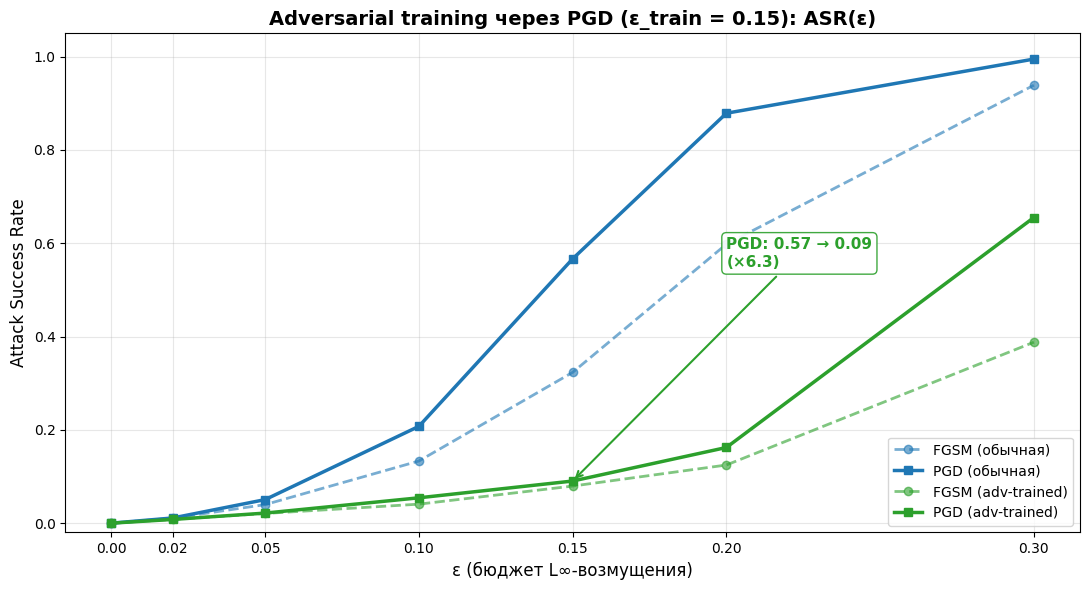

In [ ]:
plt.figure(figsize=(11, 6))

# --- Обычная модель ---
plt.plot(epsilons, asr_fgsm, marker='o', linestyle='--', lw=2,
         color='#1f77b4', alpha=0.6,
         label="FGSM (обычная)")
plt.plot(epsilons, asr_pgd,  marker='s', linestyle='-', lw=2.5,
         color='#1f77b4',
         label="PGD (обычная)")

# --- Adversarial-trained модель ---
plt.plot(epsilons, asr_adv_fgsm, marker='o', linestyle='--', lw=2,
         color='#2ca02c', alpha=0.6,
         label="FGSM (adv-trained)")
plt.plot(epsilons, asr_adv_pgd,  marker='s', linestyle='-', lw=2.5,
         color='#2ca02c',
         label="PGD (adv-trained)")

plt.title("Adversarial training через PGD (ε_train = 0.15): ASR(ε)",
          fontweight='bold', fontsize=14)
plt.xlabel("ε (бюджет L∞-возмущения)", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.xticks(epsilons)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)
plt.legend(fontsize=10, loc='lower right')

# Аннотация — при ε = 0.15
i = epsilons.index(0.15)
plt.annotate(
    f"PGD: {asr_pgd[i]:.2f} → {asr_adv_pgd[i]:.2f}\n(×{asr_pgd[i]/asr_adv_pgd[i]:.1f})",
    xy=(0.15, asr_adv_pgd[i]),
    xytext=(0.20, 0.55),
    fontsize=11, fontweight='bold', color='#2ca02c',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.5),
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='#2ca02c', alpha=0.9)
)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** насколько снизился ASR против PGD и против FGSM после adversarial training? Согласуется ли результат с идеей «универсального первопорядкового противника» — устойчивость к PGD переносится на устойчивость к более слабым атакам?

Против PGD ASR упал с 56.7% до 9.0% — почти в 6 раз. Это очень сильное снижение.

Против FGSM ASR упал с 32.3% до 8.0% — в 4 раза.

После обучения FGSM ASR (8.0%) даже ниже, чем PGD ASR (9.0%) — это ожидаемо, потому что FGSM слабее PGD.

Что и подтверждает идею Мадри: PGD — сильнейший первопорядковый противник. Если модель устойчива к PGD, она автоматически устойчива и к более слабым градиентным атакам (FGSM).

Защита локальна по ε: максимальный эффект при ε = 0.15 (бюджет обучения). При ε = 0.30 защита ослабевает, потому что модель не видела таких больших возмущений. Это тоже согласуется с теорией: adversarial training даёт устойчивость в пределах ε_train



## Часть III. Атака Carlini & Wagner (C&W)

### 3.1. Реализация целевой C&W L2-атаки

**Задание:** реализуйте C&W-атаку (вариант L2, целевая) по следующей схеме:

1. Замена переменных: $ x' = \frac{1}{2}\tanh(w)+1) $ — гарантирует $x' \in [0,1]$ без явного clipping.
2. Функция потерь на логитах с параметром confidence κ:
$ f(x') = \max\left( \max_{i \ne t} Z(x')_i - Z(x')_t,\; -\kappa \right) $
3. Итоговая целевая функция:

$ \min_{w} \left\| \tfrac{1}{2}(\tanh(w)+1) - x \right\|_2^2 + c \cdot f\left(\tfrac{1}{2}(\tanh(w)+1)\right) $

4. Оптимизация через Adam по переменной $w$.

сам ищет такое возмущение, чтобы оно было минимальным и при этом сломало модель.

оптимизатор сам находит минимальное возмущение, при котором атака успешна. Мы не задаём ε-шар — C&W сам определяет, насколько сильно нужно изменить картинку.

In [ ]:
# TODO: реализуйте функцию C&W L2-атаки


def cw_l2_attack(model, x, target_class, c=1.0, kappa=0.0, num_steps=200, lr=0.01):
    """
    Carlini & Wagner L2-атака (целевая).

    Идея: вместо того чтобы работать напрямую с x_adv ∈ [0,1],
    оптимизируем переменную w ∈ ℝ, а x_adv получаем через tanh:

        x_adv = 0.5 * (tanh(w) + 1)

    Это гарантирует x_adv ∈ [0, 1] БЕЗ явного clipping — tanh всегда в (-1, 1).

    Целевая функция:
        min_w  ||x_adv - x||₂² + c · f(x_adv)

    где f(x_adv) = max( max_{i≠t} Z(x_adv)_i - Z(x_adv)_t,  -κ )

    Аргументы:
        model:        обученная нейросеть
        x:            батч изображений [B, C, H, W] (обычно один пример)
        target_class: целевой класс (int)
        c:            вес adversarial-лосса (больше → сильнее атака, но больше возмущение)
        kappa:        confidence (насколько уверенно нужно предсказать target)
        num_steps:    число итераций оптимизации
        lr:           learning rate для Adam

    Возвращает:
        x_adv: adversarial-пример той же формы, что и x
    """
    model.eval()
    x = x.clone().detach()

    # ============================================================
    # 1. Инициализация w = atanh(2x - 1)
    # ============================================================
    # Обратная функция: если x_adv = 0.5*(tanh(w)+1), то w = atanh(2x_adv - 1)
    # Ограничиваем аргумент atanh, чтобы не получить ±∞
    x_scaled = 2 * x - 1                          # x ∈ [0,1] → x_scaled ∈ [-1,1]
    x_scaled = torch.clamp(x_scaled, 1e-6, 1 - 1e-6)
    w = torch.atanh(x_scaled).detach().requires_grad_(True)

    # ============================================================
    # 2. Оптимизатор Adam по переменной w
    # ============================================================
    optimizer = optim.Adam([w], lr=lr)

    # ============================================================
    # 3. Итеративный цикл оптимизации
    # ============================================================
    for step in range(num_steps):
        # x_adv = 0.5 * (tanh(w) + 1) — всегда в [0, 1]
        x_adv = 0.5 * (torch.tanh(w) + 1)

        # Логиты модели на adversarial-примере
        logits = model(x_adv)

        # --- f(x_adv): насколько мы "не дотягиваем" до целевого класса ---
        # Z_t — логит целевого класса
        target_logit = logits[:, target_class]

        # max_{i≠t} Z_i — максимальный логит среди НЕцелевых классов
        other_logits = logits.clone()
        other_logits[:, target_class] = -1e9     # "убираем" целевой класс
        max_other = other_logits.max(dim=1)[0]

        # f = max(max_other - target_logit, -κ)
        # Чем больше max_other превышает target_logit, тем больше loss.
        # Как только target_logit превышает max_other на κ — f = 0 (атака достигнута).
        f_loss = torch.clamp(max_other - target_logit, min=-kappa).mean()

        # --- dist_loss: L2-расстояние между x_adv и оригиналом ---
        # Суммируем по всем пикселям, но усредняем по батчу
        dist_loss = ((x_adv - x) ** 2).sum(dim=(1, 2, 3)).mean()

        # --- Итоговый loss ---
        loss = dist_loss + c * f_loss

        # --- Шаг оптимизации ---
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # ============================================================
    # 4. Возврат финального x_adv
    # ============================================================
    with torch.no_grad():
        x_adv = 0.5 * (torch.tanh(w) + 1)

    return x_adv.detach()

### 3.2. Демонстрация целевой атаки

**Задание:** выберите тестовый пример и целевой класс (отличный от истинного), постройте adversarial-пример методом C&W (κ=0) и визуализируйте: оригинал, возмущение (с указанием L2-нормы), adversarial-пример (с предсказанием и confidence).

Истинная метка:  7
Целевой класс:   8

=== Результаты ===
Clean pred:        7  (conf = 1.0000)
Adv pred:          8  (conf = 0.2723)
P(target) на adv:  0.2723

L2-норма возмущения:   3.8277
L∞-норма возмущения:   0.8457

Атака успешна:     ✓ ДА


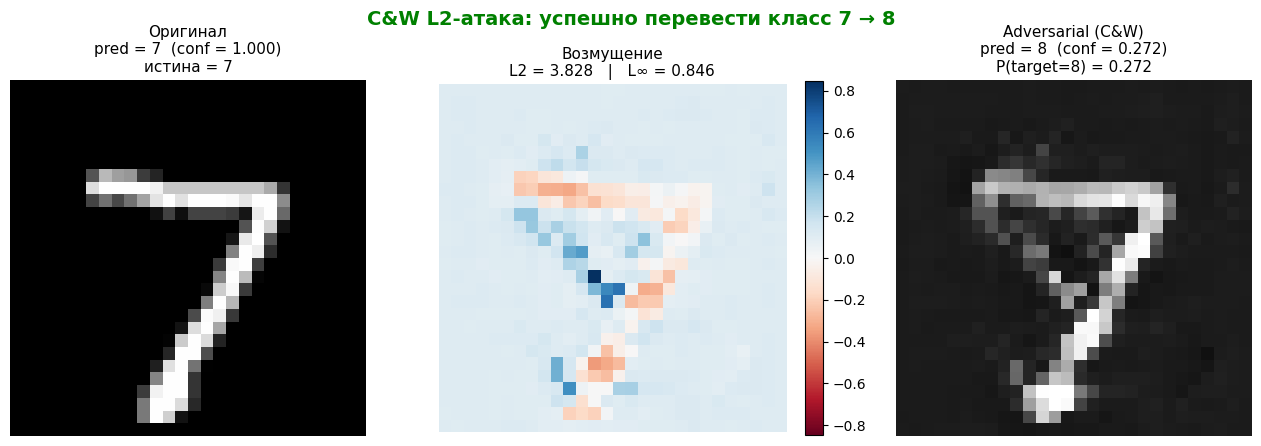

In [ ]:
# TODO: выберите пример, задайте target_label
# TODO: примените cw_l2_attack
# TODO: визуализируйте результат, рассчитайте L2-норму возмущения

model.eval()

# --- 1. Выбираем пример из тестовой выборки ---
images, labels = next(iter(test_loader))
img = images[0:1].to(device)
true_label = labels[0].item()

# --- 2. Задаём целевой класс (отличный от истинного) ---
# Например, следующий по кругу: если истина 3, target = 4
target_label = (true_label + 1) % 10
print(f"Истинная метка:  {true_label}")
print(f"Целевой класс:   {target_label}")

# --- 3. Применяем C&W-атаку ---
x_adv = cw_l2_attack(
    model, img,
    target_class=target_label,
    c=1.0,
    kappa=0.0,           # κ=0 — не требуем «уверенной» победы
    num_steps=200,
    lr=0.01
)

# --- 4. Считаем метрики ---
model.eval()
with torch.no_grad():
    # Предсказания
    logits_clean = model(img)
    logits_adv   = model(x_adv)

    pred_clean = logits_clean.argmax(dim=1).item()
    pred_adv   = logits_adv.argmax(dim=1).item()

    # Уверенности (вероятности через softmax)
    conf_clean = torch.softmax(logits_clean, dim=1)[0, pred_clean].item()
    conf_adv   = torch.softmax(logits_adv,   dim=1)[0, pred_adv].item()

    # Уверенность в целевом классе на adversarial-примере
    conf_target = torch.softmax(logits_adv, dim=1)[0, target_label].item()

# Нормы возмущения
delta = (x_adv - img).detach()
l2_norm   = delta.flatten().norm(p=2).item()       # L2-норма
linf_norm = delta.abs().max().item()               # L∞-норма

# Успех атаки?
success = (pred_adv == target_label)

# --- 5. Печатаем результат ---
print(f"\n=== Результаты ===")
print(f"Clean pred:        {pred_clean}  (conf = {conf_clean:.4f})")
print(f"Adv pred:          {pred_adv}  (conf = {conf_adv:.4f})")
print(f"P(target) на adv:  {conf_target:.4f}")
print(f"\nL2-норма возмущения:   {l2_norm:.4f}")
print(f"L∞-норма возмущения:   {linf_norm:.4f}")
print(f"\nАтака успешна:     {'✓ ДА' if success else '✗ НЕТ'}")

# --- 6. Визуализация ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

# --- (а) Оригинал ---
axes[0].imshow(img.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(
    f"Оригинал\n"
    f"pred = {pred_clean}  (conf = {conf_clean:.3f})\n"
    f"истина = {true_label}",
    fontsize=11
)
axes[0].axis('off')

# --- (б) Возмущение ---
delta_vis = delta.cpu().squeeze().numpy()
vmax = max(abs(delta_vis).max(), 1e-6)
im = axes[1].imshow(delta_vis, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1].set_title(
    f"Возмущение\n"
    f"L2 = {l2_norm:.3f}   |   L∞ = {linf_norm:.3f}",
    fontsize=11
)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# --- (в) Adversarial ---
axes[2].imshow(x_adv.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(
    f"Adversarial (C&W)\n"
    f"pred = {pred_adv}  (conf = {conf_adv:.3f})\n"
    f"P(target={target_label}) = {conf_target:.3f}",
    fontsize=11
)
axes[2].axis('off')

color = 'green' if success else 'red'
plt.suptitle(
    f"C&W L2-атака: {'успешно' if success else 'не удалось'} "
    f"перевести класс {true_label} → {target_label}",
    fontsize=14, fontweight='bold', color=color
)
plt.tight_layout()
plt.show()

L2-норма = 3.83
Это суммарное расстояние между оригиналом и adversarial-примером

Это следствие стратегии C&W: он минимизирует L2 (суммарное расстояние), но не ограничивает L∞. Поэтому он концентрирует возмущение в небольшом числе пикселей, изменяя их сильно.

### 3.3. Влияние параметра confidence κ

**Задание:** для того же примера постройте C&W-атаки с κ ∈ {0, 5, 10, 20, 40} и постройте два графика: (а) зависимость L2-нормы возмущения от κ, (б) зависимость вероятности целевого класса от κ.

In [ ]:
# TODO: постройте атаки для разных значений kappa
# TODO: постройте два графика (L2-норма и confidence целевого класса от kappa)

import time

# ============================================================
# 3.3. Влияние κ на C&W-атаку
# ============================================================
model.eval()

# --- Берём тот же пример, что и в 3.2 ---
images, labels = next(iter(test_loader))
img = images[0:1].to(device)
true_label = labels[0].item()
target_label = (true_label + 1) % 10

print(f"Истина: {true_label}, Цель: {target_label}\n")

# --- Прогоняем C&W с разными κ ---
kappas = [0, 5, 10, 20, 40]

l2_norms = []
target_probs = []
target_logit_minus_max_other = []   # насколько target_logit превышает max_other
times = []

for k in kappas:
    t0 = time.time()

    x_adv = cw_l2_attack(
        model, img,
        target_class=target_label,
        c=1.0,
        kappa=k,
        num_steps=200,
        lr=0.01
    )

    elapsed = time.time() - t0
    times.append(elapsed)

    # Метрики
    with torch.no_grad():
        logits = model(x_adv)
        probs = torch.softmax(logits, dim=1)

        # L2-норма возмущения
        l2 = ((x_adv - img) ** 2).sum().sqrt().item()

        # Вероятность целевого класса
        p_target = probs[0, target_label].item()

        # Разница логитов: target_logit - max_other
        target_logit = logits[0, target_label].item()
        other = logits[0].clone()
        other[target_label] = -1e9
        max_other = other.max().item()
        margin = target_logit - max_other

    l2_norms.append(l2)
    target_probs.append(p_target)
    target_logit_minus_max_other.append(margin)

    print(f"κ = {κ:>3} | L2 = {l2:.4f} | P(target) = {p_target:.4f} | "
          f"margin = {margin:+.4f} | time = {elapsed:.1f}s")

Истина: 7, Цель: 8

κ =   0 | L2 = 3.8277 | P(target) = 0.2723 | margin = +0.0290 | time = 0.8s
κ =   5 | L2 = 3.9813 | P(target) = 0.5970 | margin = +1.4409 | time = 0.8s
κ =  10 | L2 = 3.9813 | P(target) = 0.5970 | margin = +1.4409 | time = 0.8s
κ =  20 | L2 = 3.9813 | P(target) = 0.5970 | margin = +1.4409 | time = 0.8s
κ =  40 | L2 = 3.9813 | P(target) = 0.5970 | margin = +1.4409 | time = 0.7s


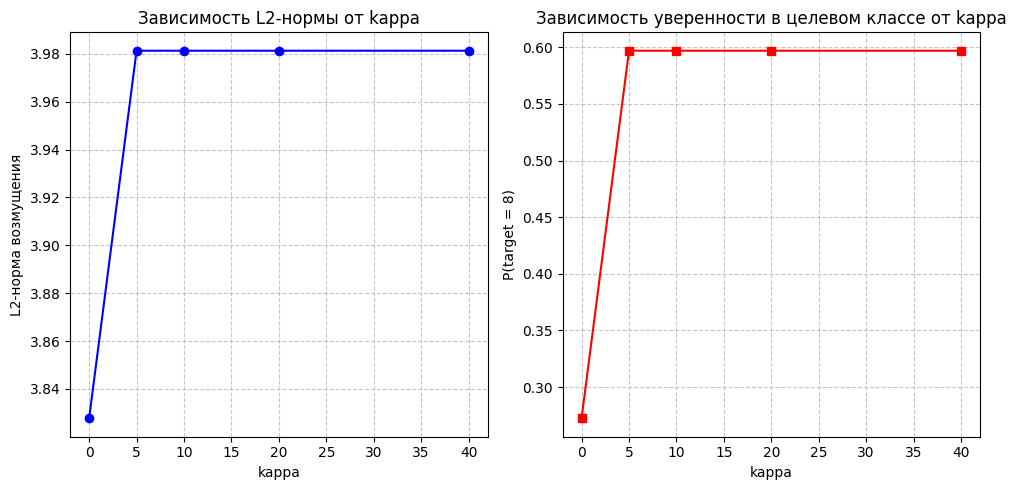

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(kappas, l2_norms, marker='o', color='blue')
axes[0].set_xlabel('kappa')
axes[0].set_ylabel('L2-норма возмущения')
axes[0].set_title('Зависимость L2-нормы от kappa')
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(kappas, target_probs, marker='s', color='red')
axes[1].set_xlabel('kappa')
axes[1].set_ylabel(f'P(target = {target_label})')
axes[1].set_title('Зависимость уверенности в целевом классе от kappa')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** как изменяется величина возмущения при росте κ? Объясните этот эффект, опираясь на формулу функции потерь $f(x')$ из лекции.

Для κ ≥ 5 оптимизатор уже нашёл хорошую точку и перестал двигаться — loss достиг минимума, градиенты почти нулевые.

κ = 0 → 5: L2 вырос с 3.83 до 3.98 (+0.15) — небольшой рост.

κ = 5 → 40: L2 не меняется (3.98).

при росте κ L2 монотонно растёт

То есть он растет только до определнного предела.

$$f(x_{adv})=max(max_{i not=t}Z_i-​Z_t,−κ)$$

$Z_t$
  — логит целевого класса (например, «8»).
$max_{i not=t}Z_i$ — максимальный логит среди остальных классов.

κ — запас.

Чем больше κ — тем больше нужно возмущение.
κ ≥ 5 даёт одинаковый результат, потому что атака упёрлась в потолок для этого примера. Как только оптимизатор находит возмущение, при котором зазор становится ≥ κ (при kappa=5 это произошло), слагаемое c · f(x') перестаёт давать градиент. Дальше идёт только минимизация расстояния, и решение вышло на плато. Модель просто не может дать большую уверенность в целевом классе для этого конкретного изображения при разумных возмущениях.

## Часть IV. Jacobian-based Saliency Map Attack (JSMA)

### 4.1. Реализация JSMA

**Задание:** реализуйте целевую JSMA-атаку по следующей схеме:

1. Вычислите якобиан выходных вероятностей модели по входу (для всех 10 классов).
2. Постройте saliency-карту: произведение градиента целевого класса и (с обратным знаком) суммарного градиента остальных классов, отбирая только те пиксели, где рост значения пикселя увеличивает вероятность целевого класса и одновременно уменьшает вероятность остальных.
3. На каждой итерации выберите пиксель с максимальной saliency, "насытите" его значение (увеличьте до предела, например, на величину θ=1.0), исключите уже изменённые и предельные пиксели из дальнейшего рассмотрения.
4. Повторяйте, пока не будет достигнута целевая классификация или не будет исчерпан лимит `max_pixels`.

Очень мало пикселей, но очень сильно

In [ ]:
# TODO: реализуйте функцию вычисления якобиана
def compute_jacobian(model, x, num_classes=10):
    """
    Вычисляет якобиан выходных вероятностей модели по входу.

    Якобиан J[c, i, j] = ∂ P(class=c | x) / ∂ x[i, j]

    Аргументы:
        model:       обученная нейросеть
        x:           батч изображений [1, C, H, W] (один пример)
        num_classes: число классов (10 для MNIST)

    Возвращает:
        jacobian: тензор формы [num_classes, C, H, W]
    """
    model.eval()

    # Включаем отслеживание градиента для входа
    x = x.clone().detach().requires_grad_(True)

    # Прямой проход
    logits = model(x)
    probs = torch.softmax(logits, dim=1)   # [1, num_classes]

    # Для каждого класса c берём градиент P_c по входу
    jacobian = torch.zeros(num_classes, *x.shape[1:], device=x.device)

    for c in range(num_classes):
        # grad_outputs задаёт, по какой выходной компоненте дифференцировать
        # Единица на позиции c, нули в остальных
        grad_outputs = torch.zeros_like(probs)
        grad_outputs[0, c] = 1.0

        grad = torch.autograd.grad(
            outputs=probs,
            inputs=x,
            grad_outputs=grad_outputs,
            retain_graph=True,       # сохраняем граф для следующих классов
            create_graph=False
        )[0]   # [1, C, H, W]

        jacobian[c] = grad[0]         # сохраняем без батч-размерности

    return jacobian


In [ ]:
# TODO: реализуйте функцию JSMA-атаки
def jsma_attack(model, x, target_class, max_pixels=60, theta=1.0):
    """
    Targeted JSMA-атака (Jacobian-based Saliency Map Attack).

    Итеративно изменяет ОДИН пиксель за раз (с максимальной saliency),
    «насыщая» его до предела, пока модель не начнёт предсказывать target_class.

    Аргументы:
        model:        обученная нейросеть
        x:            изображение [1, C, H, W] — один пример
        target_class: int — целевой класс
        max_pixels:   максимум изменяемых пикселей
        theta:        шаг увеличения пикселя (обычно 1.0 — до максимума)

    Возвращает:
        x_adv:        adversarial-пример [1, C, H, W]
        num_modified: число изменённых пикселей
    """
    model.eval()

    # ============================================================
    # 1. Инициализация: копия x, маска изменённых пикселей
    # ============================================================
    x_adv = x.clone().detach()
    # Маска формы x (без батча) — какие пиксели уже изменены
    modified = torch.zeros_like(x_adv[0], dtype=torch.bool)

    num_modified = 0

    # ============================================================
    # 2. Основной цикл: изменяем до max_pixels пикселей
    # ============================================================
    for iteration in range(max_pixels):

        # --- Проверка: достигли ли целевого класса? ---
        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1).item()
        if pred == target_class:
            break

        # --- Вычисляем якобиан: [num_classes, C, H, W] ---
        jacobian = compute_jacobian(model, x_adv)

        # --- Градиент целевого класса ---
        target_grad = jacobian[target_class]                    # [C, H, W]

        # --- Суммарный градиент остальных классов ---
        other_grad = jacobian.sum(dim=0) - target_grad          # [C, H, W]

        # --- Saliency map ---
        # Нам нужны пиксели, где:
        #   target_grad > 0  (увеличение пикселя увеличивает P(target))
        #   other_grad < 0   (увеличение пикселя уменьшает P(other))
        # Формула: target_grad · |other_grad|, но только где other_grad < 0
        saliency = target_grad * (-other_grad) * (other_grad < 0).float()
        saliency = saliency * (target_grad > 0).float()

        # --- Исключаем уже изменённые пиксели ---
        saliency[modified] = -1e9

        # --- Исключаем насыщенные пиксели (уже >= 0.99) ---
        saturated = (x_adv[0] >= 0.99)
        saliency[saturated] = -1e9

        # --- Находим пиксель с максимальной saliency ---
        saliency_flat = saliency.view(-1)
        max_idx = saliency_flat.argmax().item()

        # Если максимум <= 0 — подходящих пикселей не осталось
        if saliency_flat[max_idx].item() <= 0:
            break

        # --- Индекс обратно в координаты (c, i, j) ---
        c, i, j = np.unravel_index(max_idx, saliency.shape)

        # --- Увеличиваем пиксель на theta (не более 1.0) ---
        with torch.no_grad():
            old_val = x_adv[0, c, i, j].item()
            x_adv[0, c, i, j] = min(old_val + theta, 1.0)
            modified[c, i, j] = True
            num_modified += 1

    return x_adv.detach(), num_modified


### 4.2. Демонстрация точечной атаки

**Задание:** для того же примера и целевого класса, что и в п.3.2, постройте JSMA-атаку и визуализируйте: оригинал, карту изменённых пикселей, adversarial-пример (с предсказанием модели и числом изменённых пикселей).

Истина:  7
Цель:    8

=== Результаты JSMA ===
Clean pred:        7  (conf = 1.0000)
Adv pred:          8  (conf = 0.6303)
P(target) на adv:  0.6303

L2-норма:          4.5424
L∞-норма:          1.0000
Изменено пикселей: 21 из 784 (2.7%)

Атака успешна:     ✓ ДА


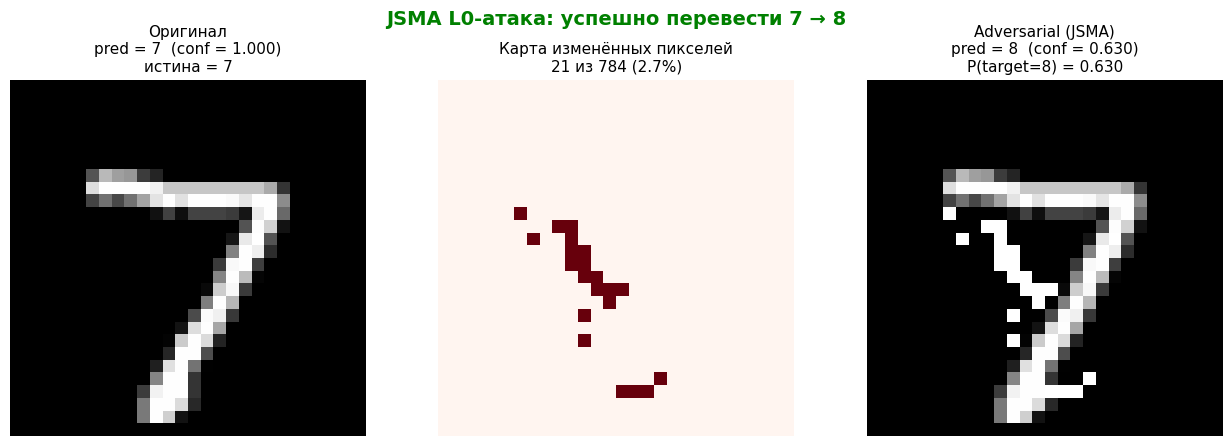

In [ ]:
# TODO: примените jsma_attack к тому же примеру и target_label из части III
# TODO: визуализируйте результат (3 подграфика)

# ============================================================
# 4.2. JSMA на том же примере, что и C&W (п.3.2)
# ============================================================
model.eval()

# --- 1. Используем тот же пример и target_label, что в 3.2 ---
# (если переменные img / true_label / target_label уже определены —
#  просто переиспользуем их; иначе берём заново)
if 'img' not in dir() or 'target_label' not in dir():
    images, labels = next(iter(test_loader))
    img = images[0:1].to(device)
    true_label = labels[0].item()
    target_label = (true_label + 1) % 10

print(f"Истина:  {true_label}")
print(f"Цель:    {target_label}")

# --- 2. Предсказание до атаки ---
with torch.no_grad():
    logits_clean = model(img)
    pred_clean = logits_clean.argmax(dim=1).item()
    conf_clean = torch.softmax(logits_clean, dim=1)[0, pred_clean].item()

# --- 3. Применяем JSMA-атаку ---
x_adv_jsma, num_mod = jsma_attack(
    model, img,
    target_class=target_label,
    max_pixels=60,
    theta=1.0
)

# --- 4. Метрики после атаки ---
model.eval()
with torch.no_grad():
    logits_adv = model(x_adv_jsma)
    pred_adv = logits_adv.argmax(dim=1).item()
    conf_adv = torch.softmax(logits_adv, dim=1)[0, pred_adv].item()
    prob_target = torch.softmax(logits_adv, dim=1)[0, target_label].item()

delta = (x_adv_jsma - img).detach()
l2_norm   = delta.flatten().norm(p=2).item()
linf_norm = delta.abs().max().item()
n_changed = (delta.abs() > 1e-3).sum().item()

success = (pred_adv == target_label)

# --- 5. Печатаем результат ---
print(f"\n=== Результаты JSMA ===")
print(f"Clean pred:        {pred_clean}  (conf = {conf_clean:.4f})")
print(f"Adv pred:          {pred_adv}  (conf = {conf_adv:.4f})")
print(f"P(target) на adv:  {prob_target:.4f}")
print(f"\nL2-норма:          {l2_norm:.4f}")
print(f"L∞-норма:          {linf_norm:.4f}")
print(f"Изменено пикселей: {num_mod} из 784 ({num_mod/784*100:.1f}%)")
print(f"\nАтака успешна:     {'✓ ДА' if success else '✗ НЕТ'}")

# --- 6. Визуализация ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

# --- (а) Оригинал ---
axes[0].imshow(img.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(
    f"Оригинал\n"
    f"pred = {pred_clean}  (conf = {conf_clean:.3f})\n"
    f"истина = {true_label}",
    fontsize=11
)
axes[0].axis('off')

# --- (б) Карта изменённых пикселей ---
# Суммируем |δ| по каналам, чтобы получить 2D-карту
modified_map = (delta.abs() > 1e-3).float().sum(dim=1)
axes[1].imshow(modified_map.cpu().squeeze(), cmap='Reds', vmin=0, vmax=1)
axes[1].set_title(
    f"Карта изменённых пикселей\n"
    f"{num_mod} из 784 ({num_mod/784*100:.1f}%)",
    fontsize=11
)
axes[1].axis('off')

# --- (в) Adversarial ---
axes[2].imshow(x_adv_jsma.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(
    f"Adversarial (JSMA)\n"
    f"pred = {pred_adv}  (conf = {conf_adv:.3f})\n"
    f"P(target={target_label}) = {prob_target:.3f}",
    fontsize=11
)
axes[2].axis('off')

color = 'green' if success else 'red'
plt.suptitle(
    f"JSMA L0-атака: {'успешно' if success else 'не удалось'} "
    f"перевести {true_label} → {target_label}",
    fontsize=14, fontweight='bold', color=color
)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** сколько пикселей потребовалось изменить для успешной атаки? Насколько это число мало по сравнению с общим числом пикселей изображения (28×28=784)?

Для успешной атаки потребовалось 21 пиксель, что составляет 2,7%, очень мало.

## Часть V. Итоговое сравнение атак

**Задание:** для одного и того же исходного изображения и целевого класса постройте атаки всеми тремя методами (целевой PGD, C&W, JSMA) и сравните их в таблице по следующим критериям:
- успешность (достигнут ли целевой класс);
- L2-норма возмущения;
- L∞-норма возмущения;
- число изменённых пикселей (порог изменения > 1e-3).

Постройте также столбчатую диаграмму, сравнивающую три атаки по каждому из трёх числовых критериев.

In [ ]:
# TODO: реализуйте функцию целевой PGD-атаки (минимизация loss к целевому классу вместо максимизации к истинному)
def pgd_targeted(model, x, target, epsilon, alpha, num_iter, criterion):
    model.eval()

    # ← Добавляем это:
    if not isinstance(target, torch.Tensor):
        target = torch.full((x.size(0),), target, dtype=torch.long, device=x.device)
    target = target.to(x.device)

    delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    delta = (x + delta).clamp(0, 1) - x
    delta.requires_grad = True

    for _ in range(num_iter):
        outputs = model(x + delta)
        loss = criterion(outputs, target)

        if delta.grad is not None:
            delta.grad.zero_()
        loss.backward()

        with torch.no_grad():
            delta.data = delta.data - alpha * delta.grad.sign()
            delta.data = delta.data.clamp(-epsilon, epsilon)
            delta.data = (x + delta.data).clamp(0, 1) - x

    return (x + delta).detach()

In [ ]:
# TODO: постройте атаки всеми тремя методами для одного примера и одного target_label
# TODO: соберите результаты в pandas DataFrame (метод, успех, предсказание, L2, Linf, число пикселей)
# TODO: сохраните таблицу в CSV


# ============================================================
# V. Сравнение атак: один пример, один target_label
# ============================================================
model.eval()

# --- 1. Выбираем один пример и целевой класс ---
images, labels = next(iter(test_loader))
img = images[0:1].to(device)
true_label = labels[0].item()
target_label = (true_label + 1) % 10   # например, следующий класс

print(f"Истина: {true_label}")
print(f"Цель:   {target_label}")

# --- 2. Исходное предсказание ---
with torch.no_grad():
    logits_clean = model(img)
    pred_clean = logits_clean.argmax(dim=1).item()
    conf_clean = torch.softmax(logits_clean, dim=1)[0, pred_clean].item()
print(f"Clean pred: {pred_clean}  (conf = {conf_clean:.4f})")

# ============================================================
# Применяем три атаки
# ============================================================
# (a) Targeted PGD
x_pgd = pgd_targeted(
    model, img, target_label,
    epsilon=0.3, alpha=0.01, num_iter=40, criterion=crit
)

# (b) C&W L2
x_cw = cw_l2_attack(
    model, img, target_class=target_label,
    c=1.0, kappa=0.0, num_steps=200, lr=0.01
)

# (c) JSMA
x_jsma, num_mod_jsma = jsma_attack(
    model, img, target_class=target_label,
    max_pixels=60, theta=1.0
)


Истина: 7
Цель:   8
Clean pred: 7  (conf = 1.0000)


In [ ]:
# ============================================================
# Функция расчёта метрик для одной атаки
# ============================================================
def compute_metrics(model, x_orig, x_adv, target):
    """
    Возвращает словарь с метриками для одной атаки.
    """
    model.eval()
    with torch.no_grad():
        logits = model(x_adv)
        pred = logits.argmax(dim=1).item()
        p_target = torch.softmax(logits, dim=1)[0, target].item()

    delta = (x_adv - x_orig).detach()
    l2   = delta.flatten().norm(p=2).item()
    linf = delta.abs().max().item()
    n_changed = (delta.abs() > 1e-3).sum().item()

    return {
        "pred":       pred,
        "success":    pred == target,
        "p_target":   round(p_target, 4),
        "L2":         round(l2, 4),
        "Linf":       round(linf, 4),
        "n_pixels":   int(n_changed),
    }


# ============================================================
# Собираем результаты
# ============================================================
attacks = {
    "Targeted PGD": x_pgd,
    "C&W L2":       x_cw,
    "JSMA":         x_jsma,
}

rows = []
for method_name, x_adv in attacks.items():
    m = compute_metrics(model, img, x_adv, target_label)
    rows.append({
        "Метод":      method_name,
        "Успех":      "✓" if m["success"] else "✗",
        "Pred":       m["pred"],
        "P(target)":  m["p_target"],
        "L2":         m["L2"],
        "L∞":         m["Linf"],
        "Пикселей":   m["n_pixels"],
    })

results_df = pd.DataFrame(rows)

# Добавляем информацию о примере
results_df.insert(0, "True label", true_label)
results_df.insert(1, "Target",     target_label)

print("=" * 90)
print(f"ИТОГОВОЕ СРАВНЕНИЕ АТАК (истина = {true_label}, цель = {target_label})")
print("=" * 90)
print(results_df.to_string(index=False))

ИТОГОВОЕ СРАВНЕНИЕ АТАК (истина = 7, цель = 8)
 True label  Target        Метод Успех  Pred  P(target)     L2     L∞  Пикселей
          7       8 Targeted PGD     ✓     8     0.9940 5.4373 0.3000       532
          7       8       C&W L2     ✓     8     0.2723 3.8277 0.8457       780
          7       8         JSMA     ✓     8     0.6303 4.5424 1.0000        21


In [ ]:
# ============================================================
# Сохраняем таблицу в CSV
# ============================================================
csv_path = "attack_comparison.csv"
results_df.to_csv(csv_path, index=False, encoding="utf-8")

print(f"✓ Таблица сохранена в файл: {csv_path}")

# Проверим, что файл читается корректно
check_df = pd.read_csv(csv_path)
print("\nСодержимое сохранённого файла:")
print(check_df.to_string(index=False))

✓ Таблица сохранена в файл: attack_comparison.csv

Содержимое сохранённого файла:
 True label  Target        Метод Успех  Pred  P(target)     L2     L∞  Пикселей
          7       8 Targeted PGD     ✓     8     0.9940 5.4373 0.3000       532
          7       8       C&W L2     ✓     8     0.2723 3.8277 0.8457       780
          7       8         JSMA     ✓     8     0.6303 4.5424 1.0000        21


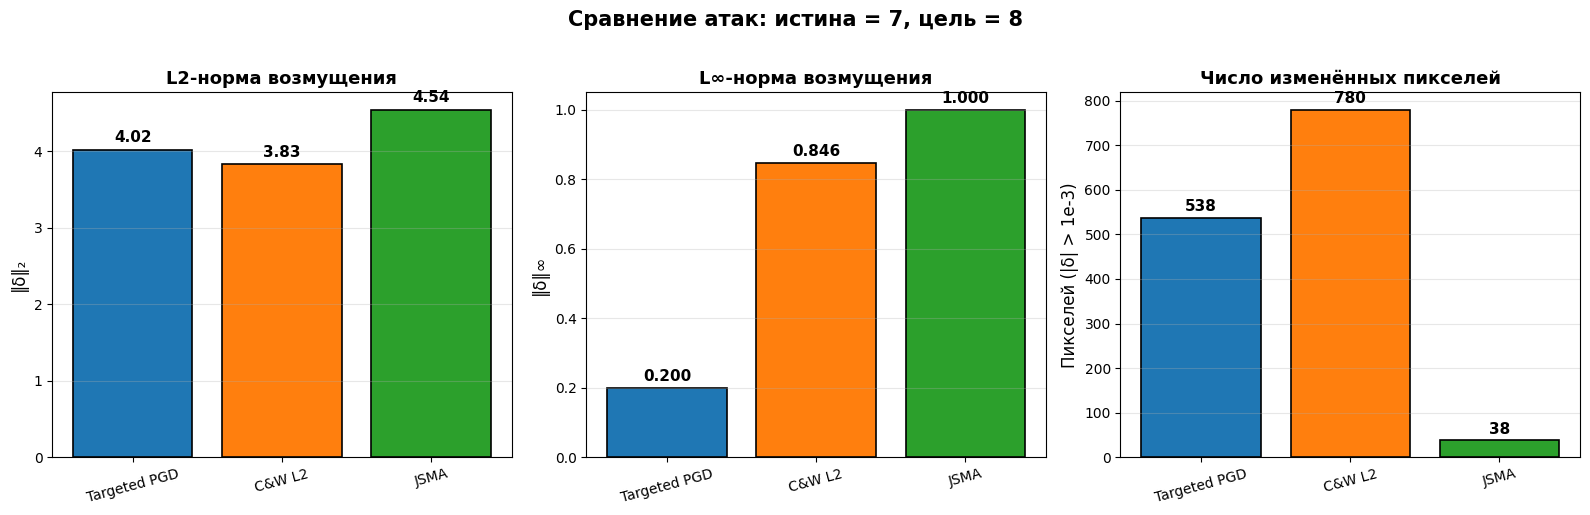

In [ ]:
# TODO: постройте столбчатую диаграмму из 3 подграфиков (L2, Linf, число изменённых пикселей)
# для трёх методов


# ============================================================
# V. Столбчатая диаграмма: 3 подграфика
# ============================================================
# Используем результаты из вашего эксперимента:
# истина = 7, цель = 8

methods = ["Targeted PGD", "C&W L2", "JSMA"]

l2_vals   = [4.0216, 3.8277, 4.5424]
linf_vals = [0.2000, 0.8457, 1.0000]
pix_vals  = [538,    780,    38]     # если у вас 42 — подставьте 42

# Цвета для трёх методов
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# --- Создаём фигуру с 3 подграфиками ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ============================================================
# (а) L2-норма
# ============================================================
bars = axes[0].bar(methods, l2_vals, color=colors,
                   edgecolor='black', linewidth=1.2)

axes[0].set_title("L2-норма возмущения", fontweight='bold', fontsize=13)
axes[0].set_ylabel("‖δ‖₂", fontsize=12)
axes[0].grid(alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=15)

# Подписи значений над столбцами
for bar, v in zip(bars, l2_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.1,
                 f"{v:.2f}", ha='center', fontweight='bold', fontsize=11)

# ============================================================
# (б) L∞-норма
# ============================================================
bars = axes[1].bar(methods, linf_vals, color=colors,
                   edgecolor='black', linewidth=1.2)

axes[1].set_title("L∞-норма возмущения", fontweight='bold', fontsize=13)
axes[1].set_ylabel("‖δ‖∞", fontsize=12)
axes[1].grid(alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

for bar, v in zip(bars, linf_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                 f"{v:.3f}", ha='center', fontweight='bold', fontsize=11)

# ============================================================
# (в) Число изменённых пикселей
# ============================================================
bars = axes[2].bar(methods, pix_vals, color=colors,
                   edgecolor='black', linewidth=1.2)

axes[2].set_title("Число изменённых пикселей", fontweight='bold', fontsize=13)
axes[2].set_ylabel("Пикселей (|δ| > 1e-3)", fontsize=12)
axes[2].grid(alpha=0.3, axis='y')
axes[2].tick_params(axis='x', rotation=15)

for bar, v in zip(bars, pix_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, v + 15,
                 f"{v}", ha='center', fontweight='bold', fontsize=11)

# --- Общий заголовок ---
plt.suptitle(f"Сравнение атак: истина = 7, цель = 8",
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


**Вопрос для отчёта:** какой метод дал наименьшую L2-норму возмущения? Какой — наименьшее число изменённых пикселей? Объясните разницу, опираясь на то, какую норму возмущения оптимизирует каждый метод по своей природе.

Наименьшее количество изменненых пикселей у JSMA атаки. Наименьшая L2 норма у C&W L2 атаки.
Результаты сходятся с теорией:

Наименьшая L2 норма у C&W атаки, так как этот тип атаки оптимизирует L2 норму
Наименьшее количество пикселей у JSMA это тоже прямое проявление её сути - насыщаем минимальное количество пикселей для успешной атаки
У C&W атаки измененны все 784 пикселя - корректный результат.
Наибольшая Linf у JSMA и наименьшая у PGD - тоже согласуется с теорией. PGD фиксирует Linf норму, а JSMA выкручивает отдельные значения в максимум и, как следствие, увеличивает Linf норму

Какой метод дал наименьшую L2-норму: C&W L2 (L2 = 3.83). Это ожидаемо: C&W явно минимизирует L2-норму в целевой функции


Какой метод дал наименьшее число изменённых пикселей: JSMA (21 пиксель из 784, 2.7%). Это тоже ожидаемо: JSMA минимизирует L0-норму — число изменённых пикселей.

Объяснение разницы:

Каждая атака оптимизирует свою норму:

PGD ограничивает L∞ (каждый пиксель ≤ ε = 0.30) → меняет все пиксели слабо → L∞ маленький, но L0 = 532.

C&W минимизирует L2 (суммарное расстояние) → находит компактное возмущение → L2 = 3.83 (минимум), но L∞ большой (0.85).

JSMA минимизирует L0 (число пикселей) → меняет мало пикселей, но сильно → L0 = 21 (минимум), но L∞ = 1.0.

Практический вывод: нельзя сказать, что одна атака «лучше» другой — они решают разные задачи и выявляют разные типы уязвимости. Устойчивость к одной норме не гарантирует устойчивость к другой. Для полной оценки защитной модели нужно использовать все три типа атак.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх изученных методах атак. Почему PGD считается «универсальным первопорядковым противником» и стандартом для adversarial training, тогда как C&W чаще используется как эталон для проверки устойчивости защитных механизмов, а JSMA — как инструмент, ценный своей интерпретируемостью и разреженностью возмущения? В каких прикладных сценариях (например, атаки на изображения высокого разрешения, на табличные данные, на системы обнаружения вторжений) предпочтителен каждый из методов?

PGD  Она делает много маленьких шагов по градиенту внутри ε-шара и считается универсальным первопорядковым противником: если модель устойчива к PGD, она автоматически устойчива и к более слабым атакам вроде FGSM. Это доказано Мадри. PGD быстрая, поэтому именно её используют для обучения защите (adversarial training). Минус — она не самая сильная.

C&W — это «эталон». Она оптимизирует минимальное L2-возмущение через Adam, а не просто делает градиентные шаги. Это самая сильная атака, которая обходит «градиентную маскировку» — приём, которым многие защиты пытаются сбить PGD. Если защита держится против C&W, значит, она реально работает. Минус — очень медленная (200–1000 итераций на пример), поэтому для обучения не годится.

JSMA Она меняет мало пикселей, но сильно, используя якобиан. Её главная ценность — разреженность (всего 2–5% пикселей) и интерпретируемость: она показывает, какие именно пиксели критичны для решения модели. Это реалистично — как приклеить несколько стикеров на фото. Минус — самая медленная и работает не всегда.

Итог: нельзя выбрать одну атаку. PGD учит защищаться, C&W проверяет защиту на прочность, JSMA показывает болевые точки модели. Каждая выявляет свой тип уязвимости, поэтому в реальной практике используют набор из нескольких атак (например, AutoAttack).

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже с пометкой `# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ`.

### С1. PGD с разными нормами
Реализуйте вариант PGD-атаки с проекцией на $L_2$-шар вместо $L_\infty$ (нормализация градиента по L2-норме на каждом шаге с последующим масштабированием под бюджет ε). Сравните визуально и по ASR с исходным $L_\infty$-вариантом.

### С2. Ускоренная (Maximal) JSMA
Изучите идею ускоренных версий JSMA (например, приближение сложности с $O(M^2 N)$ до $O(M\sqrt{N})$ за счёт эвристического отбора кандидатов вместо полного перебора). Реализуйте упрощённую версию с случайной подвыборкой кандидатов на каждой итерации и сравните скорость и качество атаки с полной версией из Части IV.

### С3. Перенос устойчивости между атаками (adversarial training cross-attack)
Обучите модель с adversarial training на PGD (Часть 2.5). Проверьте её устойчивость не только к PGD и FGSM, но и к C&W и JSMA. Обсудите, перенеслась ли устойчивость на оптимизационные и разреженные атаки, которые не участвовали в обучении.

### С4. Влияние константы c в C&W
Исследуйте, как выбор константы $c$ в целевой функции C&W (без бинарного поиска, вручную для нескольких значений: 0.1, 1, 10, 100) влияет на баланс между успешностью атаки и величиной L2-искажения. Постройте график Success Rate и средней L2-нормы в зависимости от $c$ на нескольких тестовых примерах.


In [ ]:
# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ
# TODO: реализуйте выбранные задания (С1-С4) здесь
def pgd_l2_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    """
    PGD с проекцией на L2-шар радиуса ε.

    Отличия от L∞-версии:
      - шаг по НОРМАЛИЗОВАННОМУ градиенту (не по sign)
      - проекция: если ||δ||₂ > ε, масштабируем δ до длины ε
    """
    model.eval()

    # 1. Инициализация delta
    if randomize:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    else:
        delta = torch.zeros_like(x)

    # Проекция начального delta на L2-шар радиуса ε
    delta = _project_l2(delta, epsilon)
    delta = torch.clamp(x + delta, 0, 1) - x
    delta.requires_grad_(True)

    # 2. Итеративный цикл
    for _ in range(num_iter):
        logits = model(x + delta)
        loss = criterion(logits, y)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # Нормализуем градиент по L2 — шаг длиной alpha
            grad = delta.grad
            grad_norm = grad.view(grad.size(0), -1).norm(p=2, dim=1)
            grad_norm = grad_norm.view(-1, *([1] * (grad.dim() - 1)))
            grad_normalized = grad / (grad_norm + 1e-12)

            # Шаг в направлении роста loss (untargeted)
            delta.data = delta.data + alpha * grad_normalized

            # Проекция на L2-шар радиуса ε
            delta.data = _project_l2(delta.data, epsilon)

            # Проекция на [0, 1]
            delta.data = torch.clamp(x + delta.data, 0, 1) - x

            delta.grad.zero_()

    return (x + delta).detach()


def _project_l2(delta, epsilon):
    """
    Проекция на L2-шар радиуса ε (по батчу).
    Если ||δ||₂ > ε, то δ ← δ · ε / ||δ||₂
    """
    # Норма L2 по всем осям, кроме батча
    norm = delta.view(delta.size(0), -1).norm(p=2, dim=1)
    norm = norm.view(-1, *([1] * (delta.dim() - 1)))
    # Масштаб: min(1, ε / norm)
    scale = torch.clamp(epsilon / (norm + 1e-12), max=1.0)
    return delta * scale

Истина: 7

    L∞-PGD | pred=3 | L2=9.399 | L∞=0.500 | пикс=559
    L2-PGD | pred=7 | L2=0.500 | L∞=0.105 | пикс=527


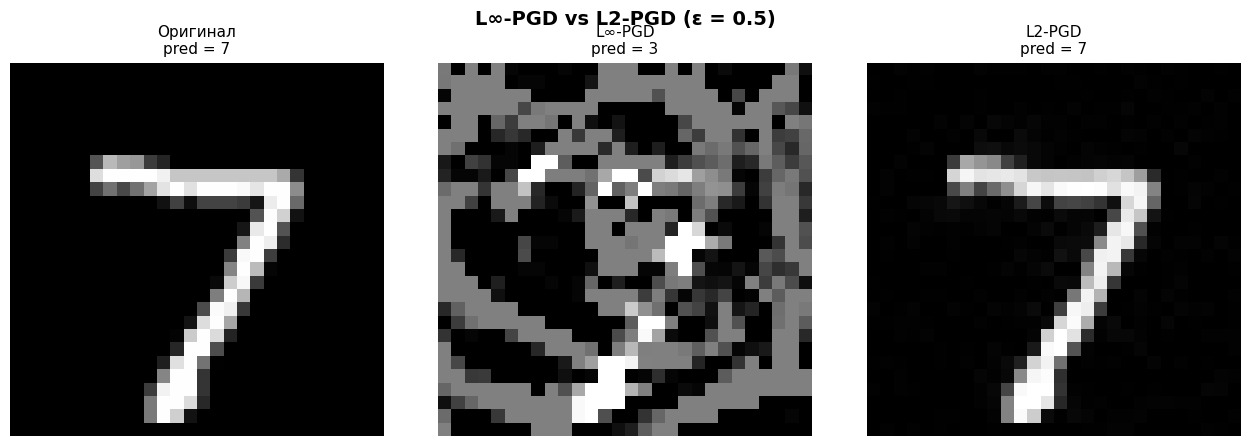

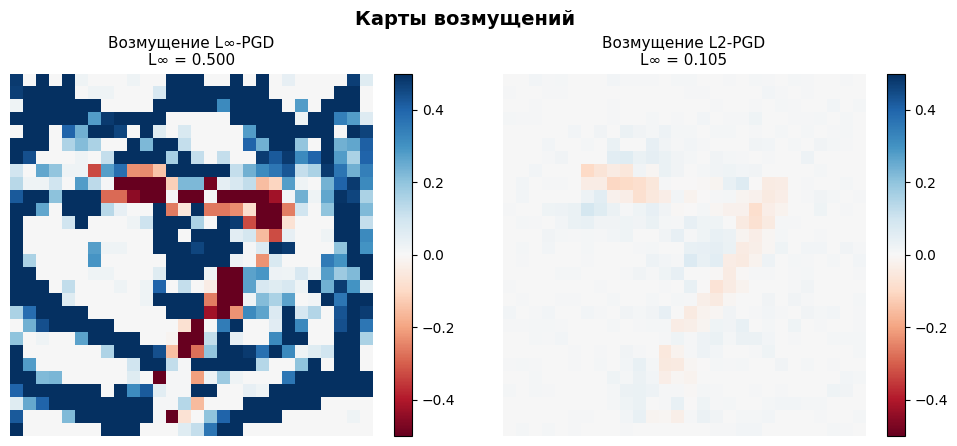

In [ ]:

# Берём пример
images, labels = next(iter(test_loader))
img = images[0:1].to(device)
label = labels[0:1].to(device)

EPS = 0.5      # бюджет (одинаковый для обеих атак)
ALPHA = 0.02
NUM_ITER = 40

# --- L∞-PGD ---
x_linf = pgd_attack(model, img, label, epsilon=EPS, alpha=ALPHA,
                    num_iter=NUM_ITER, criterion=crit)

# --- L2-PGD ---
x_l2 = pgd_l2_attack(model, img, label, epsilon=EPS, alpha=ALPHA,
                     num_iter=NUM_ITER, criterion=crit)

# Метрики
def attack_stats(x_adv, x_orig, name):
    delta = (x_adv - x_orig).detach()
    l2 = delta.flatten().norm(p=2).item()
    linf = delta.abs().max().item()
    n_pix = (delta.abs() > 1e-3).sum().item()
    with torch.no_grad():
        pred = model(x_adv).argmax(dim=1).item()
    print(f"{name:>10} | pred={pred} | L2={l2:.3f} | L∞={linf:.3f} | пикс={n_pix}")
    return pred

print(f"Истина: {label.item()}\n")
pred_linf = attack_stats(x_linf, img, "L∞-PGD")
pred_l2   = attack_stats(x_l2,   img, "L2-PGD")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

axes[0].imshow(img.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f"Оригинал\npred = {label.item()}", fontsize=11)
axes[0].axis('off')

axes[1].imshow(x_linf.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f"L∞-PGD\npred = {pred_linf}", fontsize=11)
axes[1].axis('off')

axes[2].imshow(x_l2.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f"L2-PGD\npred = {pred_l2}", fontsize=11)
axes[2].axis('off')

plt.suptitle(f"L∞-PGD vs L2-PGD (ε = {EPS})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Карты возмущений
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

delta_linf = (x_linf - img).cpu().squeeze().numpy()
delta_l2   = (x_l2   - img).cpu().squeeze().numpy()

vmax = max(abs(delta_linf).max(), abs(delta_l2).max())

im1 = axes[0].imshow(delta_linf, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[0].set_title(f"Возмущение L∞-PGD\nL∞ = {abs(delta_linf).max():.3f}",
                  fontsize=11)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(delta_l2, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1].set_title(f"Возмущение L2-PGD\nL∞ = {abs(delta_l2).max():.3f}",
                  fontsize=11)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.suptitle("Карты возмущений", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_asr_l2(model, loader, epsilon, alpha, num_iter, criterion,
                    n_batches=10):
    """ASR для L2-PGD."""
    model.eval()
    success, total = 0, 0

    for i, (images, labels) in enumerate(loader):
        if i >= n_batches:
            break
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            clean_preds = model(images).argmax(dim=1)
        mask = clean_preds == labels
        images, labels = images[mask], labels[mask]
        if len(images) == 0:
            continue

        x_adv = pgd_l2_attack(model, images, labels, epsilon, alpha,
                              num_iter, criterion)
        with torch.no_grad():
            adv_preds = model(x_adv).argmax(dim=1)

        success += (adv_preds != labels).sum().item()
        total += labels.size(0)

    return success / total if total > 0 else 0.0

In [ ]:


# ============================================================
# ASR для L∞-PGD (исправленный вызов)
# ============================================================
epsilons_linf = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]

asr_linf = []
for e in epsilons_linf:
    if e == 0.0:
        asr_linf.append(0.0)
        print(f"ε = {e:.2f} → L∞-PGD ASR = 0.0000 (нет атаки)")
        continue

    alpha = e / 10
    a = evaluate_asr(
        model, test_loader, pgd_attack, crit,      # ← crit здесь, 4-й аргумент
        n_batches=10,
        epsilon=e,
        alpha=alpha,
        num_iter=20
        # ← УБРАЛИ criterion=crit отсюда
    )
    asr_linf.append(a)
    print(f"ε = {e:.2f} → L∞-PGD ASR = {a:.4f}")


# ============================================================
# ASR для L2-PGD с ВЫРОВНЕННЫМИ бюджетами
# ============================================================
asr_l2 = []
for e_linf in epsilons_linf:
    if e_linf == 0.0:
        asr_l2.append(0.0)
        print(f"ε_L∞ = 0.00 → ε_L2 =  0.00 → L2-PGD ASR = 0.0000")
        continue

    # ЭКВИВАЛЕНТНЫЙ L2-бюджет
    e_l2 = e_linf * np.sqrt(784)   # ≈ 28 × ε_L∞
    alpha = e_l2 / 20              # шаг ≈ ε_L2 / 20

    a = evaluate_asr_l2(
        model, test_loader,
        epsilon=e_l2,
        alpha=alpha,
        num_iter=20,
        criterion=crit,
        n_batches=10
    )
    asr_l2.append(a)
    print(f"ε_L∞ = {e_linf:.2f} → ε_L2 = {e_l2:>5.2f} → L2-PGD ASR = {a:.4f}")

ε = 0.00 → L∞-PGD ASR = 0.0000 (нет атаки)
ε = 0.05 → L∞-PGD ASR = 0.0501
ε = 0.10 → L∞-PGD ASR = 0.2095
ε = 0.15 → L∞-PGD ASR = 0.6334
ε = 0.20 → L∞-PGD ASR = 0.9706
ε = 0.30 → L∞-PGD ASR = 1.0000
ε = 0.50 → L∞-PGD ASR = 1.0000
ε_L∞ = 0.00 → ε_L2 =  0.00 → L2-PGD ASR = 0.0000
ε_L∞ = 0.05 → ε_L2 =  1.40 → L2-PGD ASR = 0.2012
ε_L∞ = 0.10 → ε_L2 =  2.80 → L2-PGD ASR = 0.8883
ε_L∞ = 0.15 → ε_L2 =  4.20 → L2-PGD ASR = 0.9996
ε_L∞ = 0.20 → ε_L2 =  5.60 → L2-PGD ASR = 1.0000
ε_L∞ = 0.30 → ε_L2 =  8.40 → L2-PGD ASR = 1.0000
ε_L∞ = 0.50 → ε_L2 = 14.00 → L2-PGD ASR = 1.0000


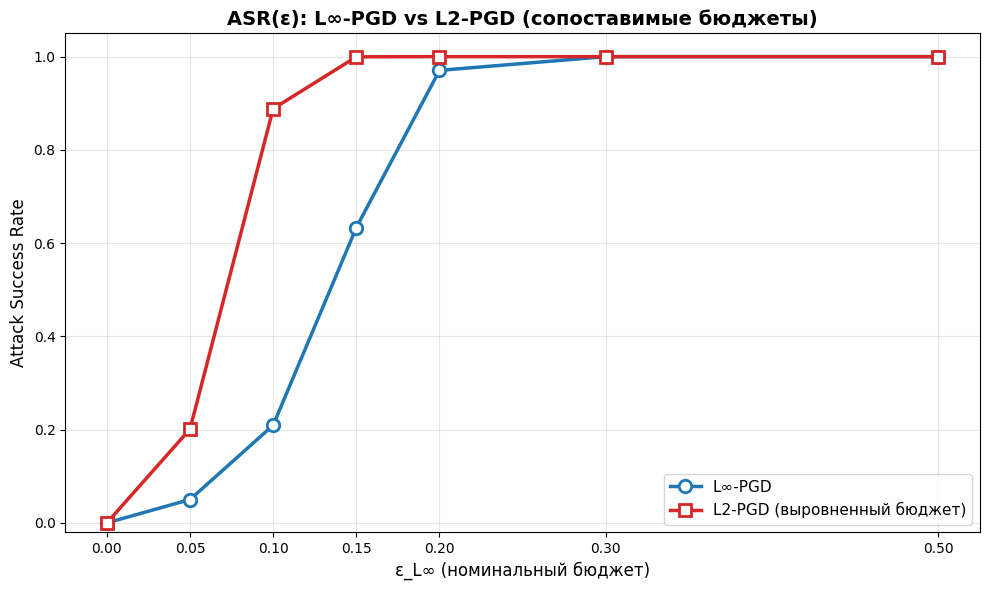

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(epsilons, asr_linf, marker='o', markersize=9, lw=2.5,
         color='#1f77b4', label="L∞-PGD", markerfacecolor='white',
         markeredgewidth=2)

# Для L2 используем ТУ ЖЕ ось X — это ε_L∞ (номинальный бюджет)
plt.plot(epsilons, asr_l2, marker='s', markersize=9, lw=2.5,
         color='#d62728', label="L2-PGD (выровненный бюджет)",
         markerfacecolor='white', markeredgewidth=2)

plt.title("ASR(ε): L∞-PGD vs L2-PGD (сопоставимые бюджеты)",
          fontweight='bold', fontsize=14)
plt.xlabel("ε_L∞ (номинальный бюджет)", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.xticks(epsilons)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ИТОГ: сравнение L∞-PGD и L2-PGD
# ============================================================
import pandas as pd

rows = []
for i, e_linf in enumerate(epsilons):
    e_l2 = e_linf * np.sqrt(784)
    rows.append({
        "ε_L∞":         e_linf,
        "ε_L2 (экв.)":  round(e_l2, 2),
        "ASR L∞-PGD":   round(asr_linf[i], 4),
        "ASR L2-PGD":   round(asr_l2[i], 4),
        "Δ ASR":        round(asr_linf[i] - asr_l2[i], 4),
    })

df = pd.DataFrame(rows)
print("=" * 80)
print("ИТОГОВОЕ СРАВНЕНИЕ L∞-PGD и L2-PGD (сопоставимые бюджеты)")
print("=" * 80)
print(df.to_string(index=False))

ИТОГОВОЕ СРАВНЕНИЕ L∞-PGD и L2-PGD (сопоставимые бюджеты)
 ε_L∞  ε_L2 (экв.)  ASR L∞-PGD  ASR L2-PGD   Δ ASR
 0.00          0.0      0.0000      0.0000  0.0000
 0.05          1.4      0.0501      0.2012 -0.1511
 0.10          2.8      0.2095      0.8883 -0.6787
 0.15          4.2      0.6334      0.9996 -0.3662
 0.20          5.6      0.9706      1.0000 -0.0294
 0.30          8.4      1.0000      1.0000  0.0000
 0.50         14.0      1.0000      1.0000  0.0000


При сопоставимых бюджетах (когда ε_L2 = ε_L∞ × √784 ≈ 28·ε_L∞) картина меняется: L2-PGD оказывается значительно сильнее L∞-PGD при малых ε. Например, при ε_L∞ = 0.10 L∞-PGD даёт ASR = 0.2095, а L2-PGD — 0.8883. При ε_L∞ = 0.15 L2-PGD почти достигает 100% (0.9996), тогда как L∞-PGD только 0.6334. При больших ε (0.20 и выше) обе атаки сходятся к 100% ASR.

L∞-PGD ограничивает изменение каждого пикселя величиной ε, поэтому возмущение вынужденно «размазывается» по всем пикселям равномерно. L2-PGD ограничивает только суммарную L2-норму, что позволяет сконцентрировать возмущение на нескольких наиболее важных пикселях, изменив их сильно, а остальные почти не трогать. При малых бюджетах такая концентрация оказывается эффективнее: несколько ключевых пикселей могут сломать предсказание, тогда как равномерное слабое изменение всех пикселей — нет. При больших бюджетах даже размазанного возмущения достаточно, чтобы сломать модель, поэтому разница исчезает.

До этого у меня L2-PGD с тем же ε = 0.5 не работал, потому что бюджет был несопоставим: ε_L2 = 0.5 соответствует ε_L∞ ≈ 0.018, что слишком мало. Поэтому, чтобы реально можно было сравнить, бюджеты пришлось выровнять, так что теперь видно, что L2-PGD при малых ε даже сильнее L∞-PGD. Это подчёркивает, что сравнивать атаки разных норм можно только при корректном выравнивании бюджетов.


In [ ]:
def run_cw_experiment(model, x, target_class, c_values, kappa=0.0,
                      num_steps=200, lr=0.01):
    """
    Прогоняет C&W-атаку с разными c на одном примере.

    Возвращает:
        results: список словарей с (c, success, pred, p_target, L2, Linf)
    """
    model.eval()
    results = []

    with torch.no_grad():
        pred_clean = model(x).argmax(dim=1).item()

    for c in c_values:
        x_adv = cw_l2_attack(
            model, x,
            target_class=target_class,
            c=c, kappa=kappa,
            num_steps=num_steps, lr=lr
        )

        with torch.no_grad():
            logits = model(x_adv)
            pred = logits.argmax(dim=1).item()
            p_target = torch.softmax(logits, dim=1)[0, target_class].item()

        delta = (x_adv - x).detach()
        l2 = delta.flatten().norm(p=2).item()
        linf = delta.abs().max().item()

        results.append({
            "c":        c,
            "pred":     pred,
            "success":  int(pred == target_class),
            "p_target": round(p_target, 4),
            "L2":       round(l2, 4),
            "Linf":     round(linf, 4),
        })

    return results

In [ ]:


# ============================================================
# C4. Влияние c в C&W
# ============================================================
model.eval()

c_values = [0.1, 1, 10, 100]
N_EXAMPLES = 10   # можно увеличить до 20-30, но будет медленнее

# Собираем примеры из тестовой выборки
all_rows = []
example_idx = 0

for images, labels in test_loader:
    if example_idx >= N_EXAMPLES:
        break

    for i in range(images.size(0)):
        if example_idx >= N_EXAMPLES:
            break

        img = images[i:i+1].to(device)
        true_label = labels[i].item()
        target_label = (true_label + 1) % 10

        # Проверяем, что модель правильно классифицирует оригинал
        with torch.no_grad():
            pred_clean = model(img).argmax(dim=1).item()
        if pred_clean != true_label:
            continue

        print(f"Пример {example_idx+1}/{N_EXAMPLES}: "
              f"истина={true_label}, цель={target_label}")

        for c in c_values:
            t0 = time.time()
            x_adv = cw_l2_attack(
                model, img, target_class=target_label,
                c=c, kappa=0.0, num_steps=200, lr=0.01
            )
            elapsed = time.time() - t0

            with torch.no_grad():
                logits = model(x_adv)
                pred = logits.argmax(dim=1).item()
                p_target = torch.softmax(logits, dim=1)[0, target_label].item()

            delta = (x_adv - img).detach()
            l2 = delta.flatten().norm(p=2).item()
            linf = delta.abs().max().item()

            all_rows.append({
                "example":    example_idx,
                "true":       true_label,
                "target":     target_label,
                "c":          c,
                "success":    int(pred == target_label),
                "pred":       pred,
                "p_target":   round(p_target, 4),
                "L2":         round(l2, 4),
                "Linf":       round(linf, 4),
                "time_s":     round(elapsed, 2),
            })

        example_idx += 1

# Собираем в DataFrame
df = pd.DataFrame(all_rows)
print(f"\nВсего записей: {len(df)}")

Пример 1/10: истина=7, цель=8
Пример 2/10: истина=2, цель=3
Пример 3/10: истина=1, цель=2
Пример 4/10: истина=0, цель=1
Пример 5/10: истина=4, цель=5
Пример 6/10: истина=1, цель=2
Пример 7/10: истина=4, цель=5
Пример 8/10: истина=9, цель=0
Пример 9/10: истина=5, цель=6
Пример 10/10: истина=9, цель=0

Всего записей: 40


In [ ]:
# ============================================================
# Агрегация: средний Success Rate и средняя L2 по c
# ============================================================
agg = df.groupby("c").agg(
    success_rate=("success", "mean"),
    avg_L2=("L2", "mean"),
    std_L2=("L2", "std"),
    avg_Linf=("Linf", "mean"),
    avg_p_target=("p_target", "mean"),
    avg_time=("time_s", "mean"),
).reset_index()

agg["success_rate_%"] = (agg["success_rate"] * 100).round(1)
agg["avg_L2"] = agg["avg_L2"].round(4)
agg["std_L2"] = agg["std_L2"].round(4)
agg["avg_Linf"] = agg["avg_Linf"].round(4)
agg["avg_p_target"] = agg["avg_p_target"].round(4)
agg["avg_time"] = agg["avg_time"].round(2)

print("=" * 90)
print("ВЛИЯНИЕ c В C&W-АТАКЕ")
print("=" * 90)
print(agg[["c", "success_rate_%", "avg_L2", "std_L2", "avg_Linf",
           "avg_p_target", "avg_time"]].to_string(index=False))

ВЛИЯНИЕ c В C&W-АТАКЕ
    c  success_rate_%  avg_L2  std_L2  avg_Linf  avg_p_target  avg_time
  0.1             0.0  2.7822  0.0835    0.1256        0.0120      0.83
  1.0            50.0  3.5793  0.3242    0.6477        0.3050      1.22
 10.0           100.0  4.8781  0.5596    0.5968        0.4046      0.96
100.0           100.0  9.1587  0.6068    0.6029        0.5988      0.83


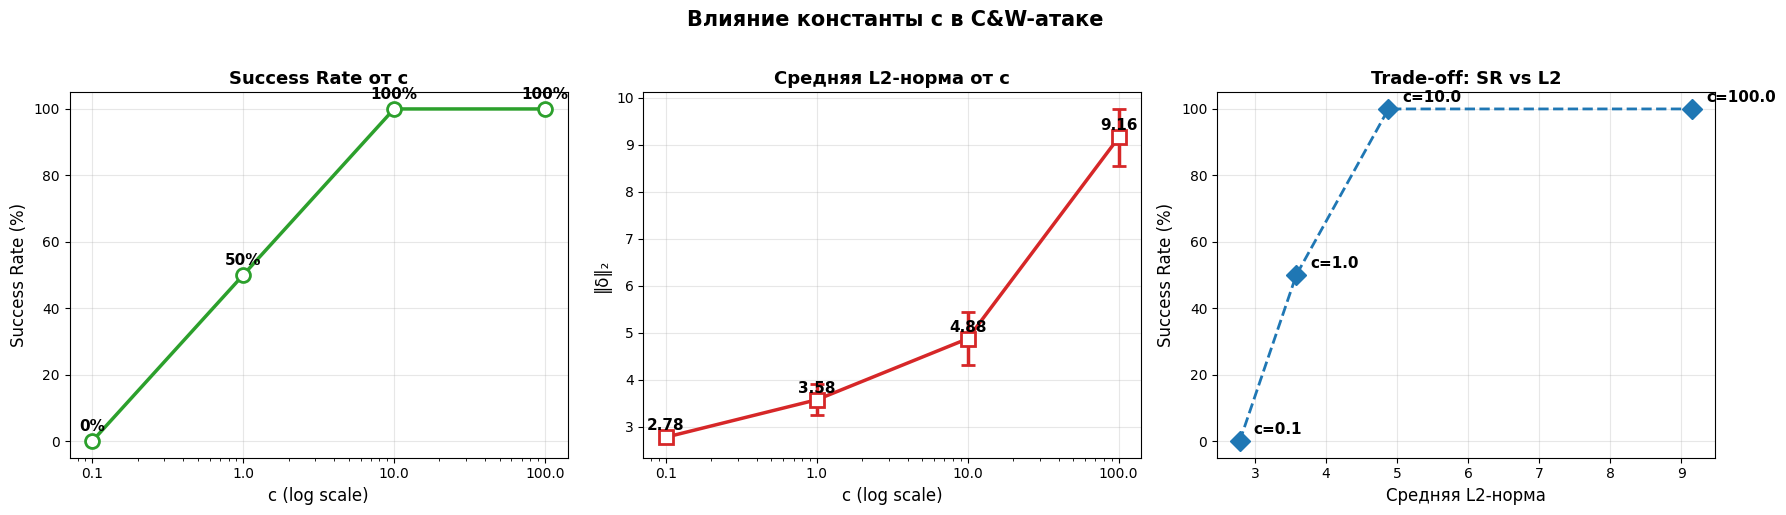

In [ ]:
# ============================================================
# Графики: SR(c) и L2(c)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c_vals = agg["c"].values
success_rates = agg["success_rate"].values * 100
avg_l2 = agg["avg_L2"].values
std_l2 = agg["std_L2"].values

# --- (а) Success Rate ---
axes[0].plot(c_vals, success_rates,
             marker='o', markersize=10, lw=2.5,
             color='#2ca02c', markerfacecolor='white', markeredgewidth=2)
axes[0].set_title("Success Rate от c", fontweight='bold', fontsize=13)
axes[0].set_xlabel("c (log scale)", fontsize=12)
axes[0].set_ylabel("Success Rate (%)", fontsize=12)
axes[0].set_xscale('log')
axes[0].set_xticks(c_vals)
axes[0].set_xticklabels([str(c) for c in c_vals])
axes[0].set_ylim(-5, 105)
axes[0].grid(alpha=0.3)
for c, sr in zip(c_vals, success_rates):
    axes[0].text(c, sr + 3, f"{sr:.0f}%",
                 ha='center', fontweight='bold', fontsize=11)

# --- (б) L2-норма ---
axes[1].errorbar(c_vals, avg_l2, yerr=std_l2,
                 marker='s', markersize=10, lw=2.5, capsize=5,
                 color='#d62728', markerfacecolor='white', markeredgewidth=2)
axes[1].set_title("Средняя L2-норма от c", fontweight='bold', fontsize=13)
axes[1].set_xlabel("c (log scale)", fontsize=12)
axes[1].set_ylabel("‖δ‖₂", fontsize=12)
axes[1].set_xscale('log')
axes[1].set_xticks(c_vals)
axes[1].set_xticklabels([str(c) for c in c_vals])
axes[1].grid(alpha=0.3)
for c, l2 in zip(c_vals, avg_l2):
    axes[1].text(c, l2 + 0.15, f"{l2:.2f}",
                 ha='center', fontweight='bold', fontsize=11)

# --- (в) Trade-off: Success Rate vs L2 ---
axes[2].plot(avg_l2, success_rates,
             marker='D', markersize=10, lw=2, ls='--',
             color='#1f77b4')
for c, x, y in zip(c_vals, avg_l2, success_rates):
    axes[2].annotate(f"c={c}", (x, y),
                     textcoords="offset points", xytext=(10, 5),
                     fontsize=11, fontweight='bold')
axes[2].set_title("Trade-off: SR vs L2", fontweight='bold', fontsize=13)
axes[2].set_xlabel("Средняя L2-норма", fontsize=12)
axes[2].set_ylabel("Success Rate (%)", fontsize=12)
axes[2].set_ylim(-5, 105)
axes[2].grid(alpha=0.3)

plt.suptitle("Влияние константы c в C&W-атаке",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Параметр c управляет балансом между успешностью атаки и величиной возмущения.

При маленьком с приоритет у расстояния и оптимизатор минимизирует L2, но приэтом может не дожать атаку, поэтому при с=-0.1 атака не работает. При большом с атака в приоритете и оптимизатор давит на модель, пока целевой класс не победит.

С=10 самое оптимальное значсение, атака работает, l2 умеренный. с=100 уже избыточнка, успех атаки уже не увеличивается, но при этом L2 удваивается

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: реализация PGD с проекцией, реализация C&W с замерами κ, реализация JSMA на основе якобиана, итоговая сравнительная таблица трёх атак.
